In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ============================================
# CELL 1 — IMPORT LIBRARIES
# ============================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

from PIL import Image

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler

import torchvision
from torchvision import transforms
from torchvision import models
from torchvision.datasets import ImageFolder

warnings.filterwarnings("ignore")

In [2]:
# ============================================
# CELL 2 — RANDOM SEED
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [3]:
# ============================================
# CELL 3 — DATASET PATH
# ============================================

DATASET_PATH = "/kaggle/input/datasets/vencerlanz09/agricultural-pests-image-dataset"

classes = sorted(os.listdir(DATASET_PATH))

print("Number of Classes :", len(classes))
print(classes)

Number of Classes : 12
['ants', 'bees', 'beetle', 'catterpillar', 'earthworms', 'earwig', 'grasshopper', 'moth', 'slug', 'snail', 'wasp', 'weevil']


In [4]:
# ============================================
# CELL 4 — IMAGE PATHS
# ============================================

all_images = []
all_labels = []

for cls in classes:

    class_dir = os.path.join(DATASET_PATH, cls)

    for img in os.listdir(class_dir):

        all_images.append(os.path.join(class_dir, img))
        all_labels.append(cls)

print("Total Images :", len(all_images))

Total Images : 5494


,Class,Count
0,ants,499
1,bees,500
2,beetle,416
3,catterpillar,434
4,earthworms,323
5,earwig,466
6,grasshopper,485
7,moth,497
8,slug,391
9,snail,500


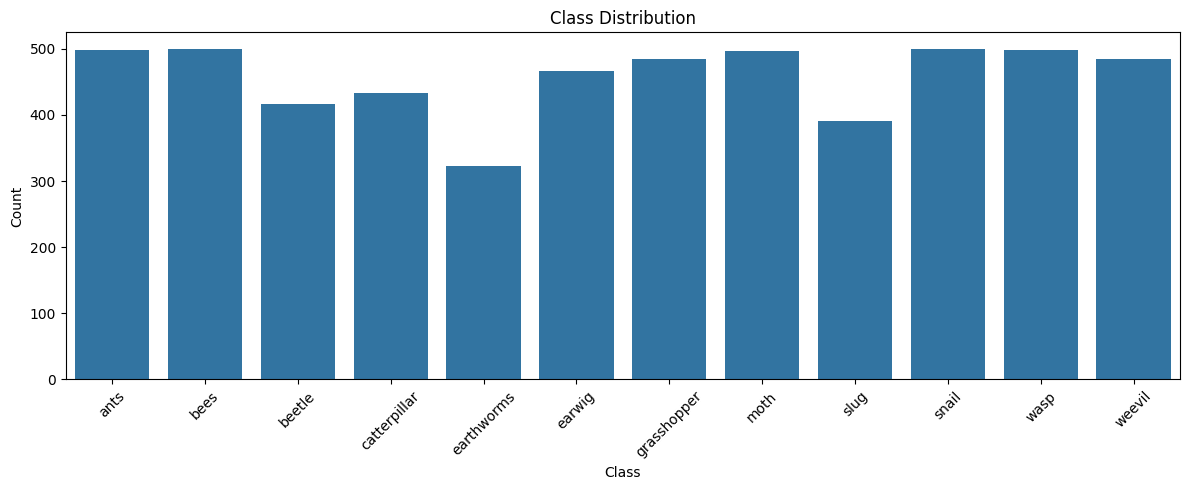

In [5]:
# ============================================
# CELL 5 — CLASS DISTRIBUTION
# ============================================

class_counts = {}

for cls in classes:

    class_counts[cls] = len(
        os.listdir(
            os.path.join(DATASET_PATH, cls)
        )
    )

df_counts = pd.DataFrame(
    class_counts.items(),
    columns=["Class","Count"]
)

display(df_counts)

plt.figure(figsize=(12,5))

sns.barplot(
    data=df_counts,
    x="Class",
    y="Count"
)

plt.xticks(rotation=45)

plt.title("Class Distribution")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/class_distribution.png",
    dpi=300
)

plt.show()

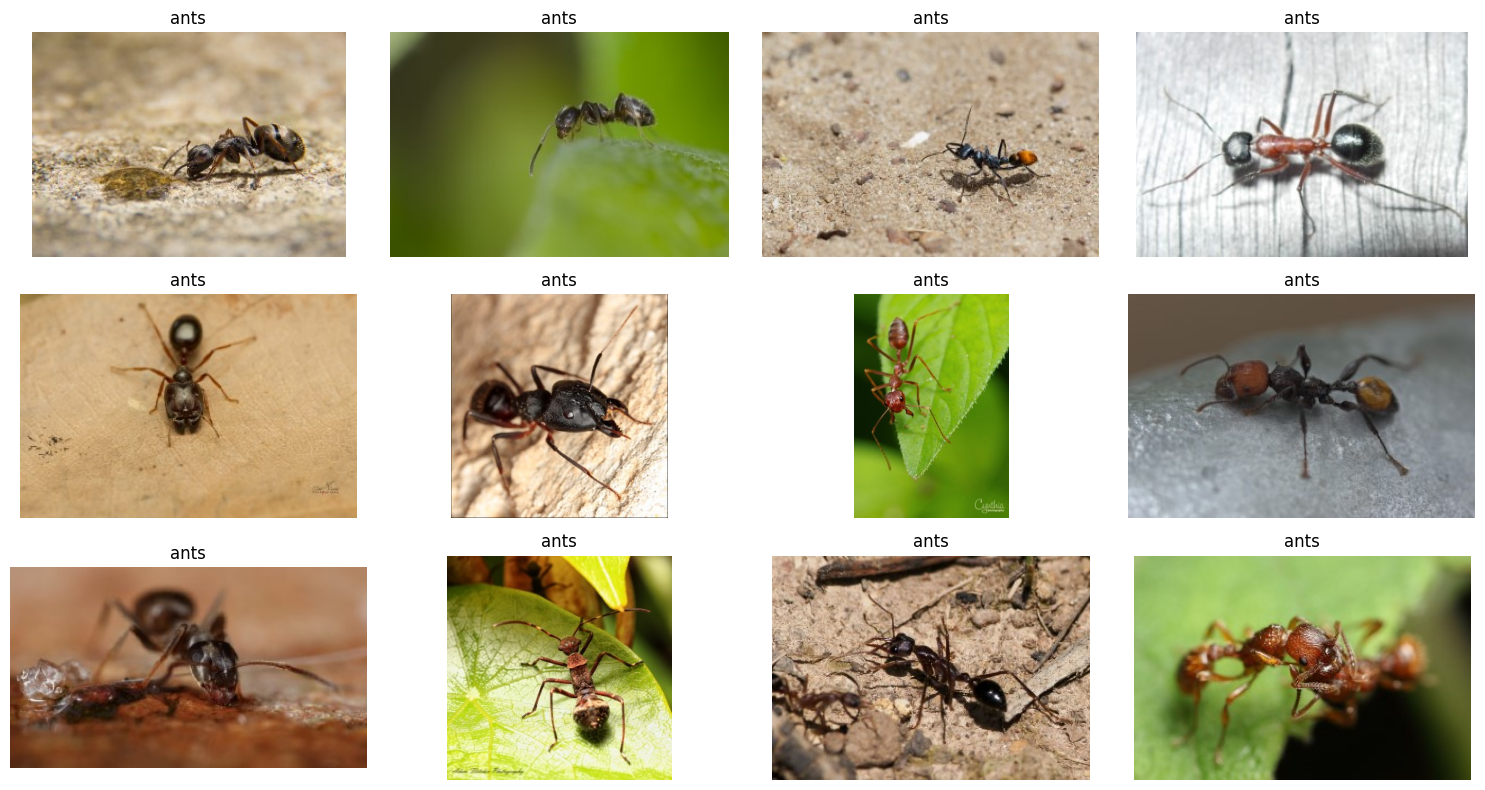

In [6]:
# ============================================
# CELL 6 — SAMPLE IMAGES
# ============================================

plt.figure(figsize=(15,8))

for i in range(12):

    img = cv2.imread(all_images[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(all_labels[i])

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/sample_images.png",
    dpi=300
)

plt.show()

In [8]:
# ============================================
# CELL 7 — CLAHE FUNCTION
# ============================================

def apply_clahe(image):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l,a,b = cv2.split(lab)

    clahe = cv2.createCLAHE(

        clipLimit=2.0,

        tileGridSize=(8,8)

    )

    l = clahe.apply(l)

    merged = cv2.merge((l,a,b))

    enhanced = cv2.cvtColor(
        merged,
        cv2.COLOR_LAB2RGB
    )

    return enhanced

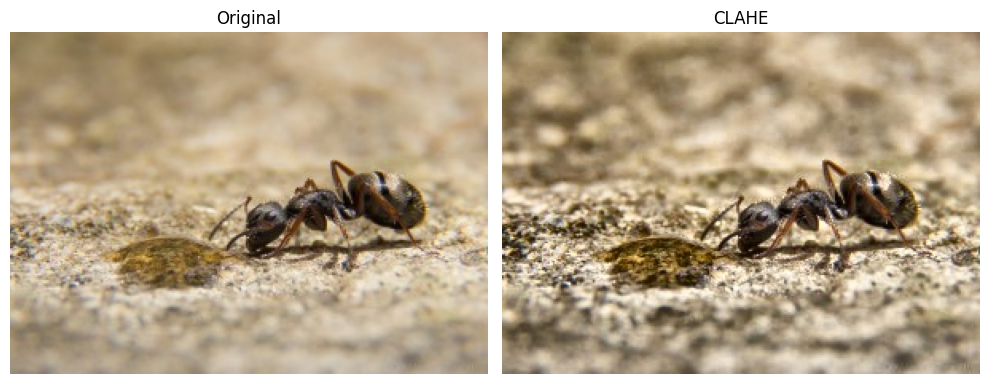

In [9]:
# ============================================
# CELL 8 — CLAHE VISUALIZATION
# ============================================

sample = cv2.imread(all_images[0])

sample = cv2.cvtColor(
    sample,
    cv2.COLOR_BGR2RGB
)

clahe = apply_clahe(sample)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(sample)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(clahe)

plt.title("CLAHE")

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/clahe.png",
    dpi=300
)

plt.show()

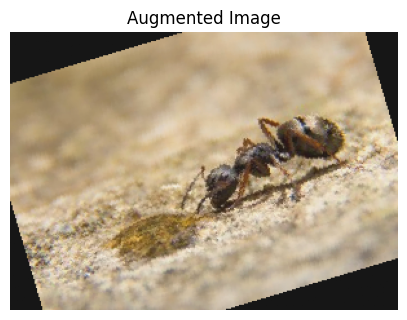

In [10]:
# ============================================
# CELL 9 — AUGMENTATION PREVIEW
# ============================================

preview_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(

        brightness=0.3,

        contrast=0.3,

        saturation=0.3

    ),

    transforms.ToTensor()

])

aug = preview_transform(sample)

plt.figure(figsize=(5,5))

plt.imshow(
    np.transpose(
        aug.numpy(),
        (1,2,0)
    )
)

plt.axis("off")

plt.title("Augmented Image")

plt.savefig(
    "/kaggle/working/augmentation_preview.png",
    dpi=300
)

plt.show()

In [11]:
# ============================================
# CELL 10 — TRAIN & VALIDATION TRANSFORMS
# ============================================

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.3),

    transforms.RandomRotation(25),

    transforms.RandomAffine(
        degrees=20,
        translate=(0.10,0.10),
        scale=(0.90,1.10)
    ),

    transforms.ColorJitter(
        brightness=0.30,
        contrast=0.30,
        saturation=0.30,
        hue=0.10
    ),

    transforms.RandomPerspective(
        distortion_scale=0.20,
        p=0.30
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02,0.10),
        ratio=(0.3,3.3)
    ),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


val_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [12]:
# ============================================
# CELL 11 — CUSTOM DATASET
# ============================================

class PestDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.dataset = ImageFolder(root_dir)

        self.transform = transform

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        img, label = self.dataset[idx]

        img = np.array(img)

        img = apply_clahe(img)

        if self.transform:

            img = self.transform(img)

        return img, label

In [13]:
# ============================================
# CELL 12 — CREATE DATASETS
# ============================================

train_dataset = PestDataset(
    DATASET_PATH,
    transform=train_transform
)

val_dataset = PestDataset(
    DATASET_PATH,
    transform=val_transform
)

print("Dataset Size :", len(train_dataset))

Dataset Size : 5494


In [14]:
# ============================================
# CELL 13 — TRAIN / VALIDATION SPLIT
# ============================================

indices = list(range(len(train_dataset)))

labels = train_dataset.dataset.targets

train_idx, val_idx = train_test_split(

    indices,

    test_size=0.20,

    stratify=labels,

    random_state=SEED

)

print("Training Samples :", len(train_idx))

print("Validation Samples :", len(val_idx))

Training Samples : 4395
Validation Samples : 1099


In [15]:
# ============================================
# CELL 14 — SAMPLERS
# ============================================

train_sampler = SubsetRandomSampler(train_idx)

val_sampler = SubsetRandomSampler(val_idx)

In [16]:
# ============================================
# CELL 15 — DATALOADERS
# ============================================

train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    sampler=train_sampler,

    num_workers=2,

    pin_memory=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    sampler=val_sampler,

    num_workers=2,

    pin_memory=True

)

In [17]:
# ============================================
# CELL 16 — VERIFY DATALOADER
# ============================================

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)

print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


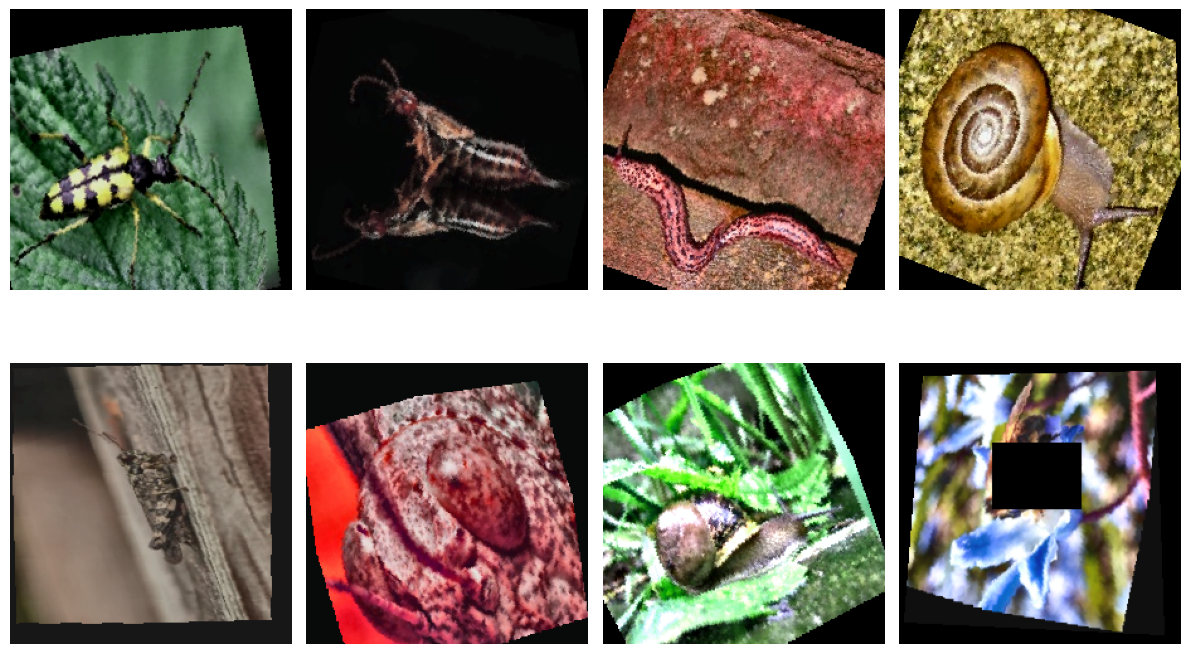

In [18]:
# ============================================
# CELL 17 — AUGMENTED IMAGES
# ============================================

plt.figure(figsize=(12,8))

for i in range(8):

    img = images[i]

    img = img.permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

    img = np.clip(img,0,1)

    plt.subplot(2,4,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/train_augmented_images.png",
    dpi=300
)

plt.show()

In [19]:
# ============================================
# CELL 18 — ADAPTIVE FEATURE FUSION (AFF)
# ============================================

class AdaptiveFusion(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.temperature = 2.0

        self.fc1 = nn.Linear(dim * 2, dim)

        # Reviewer Regularization
        self.dropout = nn.Dropout(0.40)

        self.fc2 = nn.Linear(dim, 2)

    def forward(self, cnn_feat, vit_feat):

        combined = torch.cat(
            [cnn_feat, vit_feat],
            dim=1
        )

        x = torch.relu(self.fc1(combined))

        x = self.dropout(x)

        logits = self.fc2(x)

        weights = torch.softmax(
            logits / self.temperature,
            dim=1
        )

        cnn_weight = weights[:,0:1]
        vit_weight = weights[:,1:2]

        fused = (
            cnn_weight * cnn_feat +
            vit_weight * vit_feat
        )

        return fused

In [20]:
# ============================================
# CELL 19 — HYBRID AFFN MODEL
# ============================================

class HybridModel(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # -----------------------------
        # CNN Branch
        # -----------------------------

        self.cnn = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        self.cnn.fc = nn.Identity()

        # -----------------------------
        # ViT Branch
        # -----------------------------

        self.vit = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        self.vit.heads = nn.Identity()

        # -----------------------------
        # Dimension Alignment
        # -----------------------------

        self.cnn_proj = nn.Linear(
            2048,
            768
        )

        # -----------------------------
        # Adaptive Fusion
        # -----------------------------

        self.fusion = AdaptiveFusion(768)

        # -----------------------------
        # Final Classifier
        # -----------------------------

        self.classifier = nn.Sequential(

            nn.Linear(768,512),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(512,num_classes)

        )

    def forward(self,x):

        cnn_feat = self.cnn(x)

        cnn_feat = self.cnn_proj(cnn_feat)

        vit_feat = self.vit(x)

        fused = self.fusion(
            cnn_feat,
            vit_feat
        )

        out = self.classifier(fused)

        return out

In [21]:
# ============================================
# CELL 20 — CREATE MODEL
# ============================================

num_classes = len(train_dataset.dataset.classes)

model = HybridModel(
    num_classes=num_classes
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 212MB/s]  


HybridModel(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          

In [22]:
# ============================================
# CELL 21 — MODEL PARAMETERS
# ============================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")

print(f"Trainable Parameters  : {trainable_params:,}")

Total Parameters      : 112,462,158
Trainable Parameters  : 112,462,158


In [23]:
# ============================================
# CELL 22 — LOSS FUNCTION
# ============================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.10
)

In [24]:
# ============================================
# CELL 23 — OPTIMIZER
# ============================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=3e-4,

    weight_decay=1e-4

)

In [25]:
# ============================================
# CELL 24 — LR SCHEDULER
# ============================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=15,

    eta_min=1e-6

)

In [27]:
# ============================================
# CELL 25 — EARLY STOPPING
# ============================================

best_val_acc = 0

patience = 4

counter = 0

save_path = "/kaggle/working/best_affn_model.pth"

In [28]:
# ============================================
# CELL 26 — TRAINING HISTORY
# ============================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

learning_rates = []

In [30]:
# ============================================
# CELL 27 — MIXED PRECISION
# ============================================

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

In [31]:
# ============================================
# CELL 28 — TRAINING
# ============================================

EPOCHS = 15

for epoch in range(EPOCHS):

    ##################################################
    # TRAINING
    ##################################################

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")

        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    ##################################################
    # VALIDATION
    ##################################################

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            with autocast():

                outputs = model(images)

                loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss /= len(val_loader)

    val_acc = 100 * val_correct / val_total

    ##################################################
    # STORE HISTORY
    ##################################################

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accs.append(train_acc)

    val_accs.append(val_acc)

    learning_rates.append(
        optimizer.param_groups[0]["lr"]
    )

    ##################################################
    # SCHEDULER
    ##################################################

    scheduler.step()

    ##################################################
    # EARLY STOPPING
    ##################################################

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        counter = 0

        torch.save(

            model.state_dict(),

            save_path

        )

    else:

        counter += 1

    ##################################################
    # PRINT
    ##################################################

    print()

    print("-"*60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.2f}%")

    print(f"Learning Rate : {optimizer.param_groups[0]['lr']:.7f}")

    print("-"*60)

    ##################################################
    # STOP
    ##################################################

    if counter >= patience:

        print()

        print("Early stopping activated.")

        break

Epoch [1/15]: 100%|██████████| 138/138 [01:04<00:00,  2.15it/s, loss=1.52] 



------------------------------------------------------------
Epoch 1/15
Train Loss : 1.4552
Train Acc  : 62.18%
Val Loss   : 1.1224
Val Acc    : 78.53%
Learning Rate : 0.0002967
------------------------------------------------------------


Epoch [2/15]: 100%|██████████| 138/138 [01:07<00:00,  2.06it/s, loss=1.12] 



------------------------------------------------------------
Epoch 2/15
Train Loss : 1.0159
Train Acc  : 81.43%
Val Loss   : 0.9090
Val Acc    : 85.44%
Learning Rate : 0.0002871
------------------------------------------------------------


Epoch [3/15]: 100%|██████████| 138/138 [01:07<00:00,  2.05it/s, loss=0.653]


...


------------------------------------------------------------
Epoch 13/15
Train Loss : 0.5834
Train Acc  : 98.52%
Val Loss   : 0.7382
Val Acc    : 91.81%
Learning Rate : 0.0000139
------------------------------------------------------------


Epoch [14/15]: 100%|██████████| 138/138 [01:07<00:00,  2.04it/s, loss=0.989]



------------------------------------------------------------
Epoch 14/15
Train Loss : 0.5768
Train Acc  : 98.73%
Val Loss   : 0.7387
Val Acc    : 92.81%
Learning Rate : 0.0000043
------------------------------------------------------------


Epoch [15/15]: 100%|██████████| 138/138 [01:07<00:00,  2.05it/s, loss=0.545]



------------------------------------------------------------
Epoch 15/15
Train Loss : 0.5722
Train Acc  : 98.77%
Val Loss   : 0.7337
Val Acc    : 92.72%
Learning Rate : 0.0000010
------------------------------------------------------------


In [32]:
# ============================================
# CELL 29 — LOAD BEST MODEL
# ============================================

model.load_state_dict(

    torch.load(save_path)

)

print("Best model loaded.")

Best model loaded.


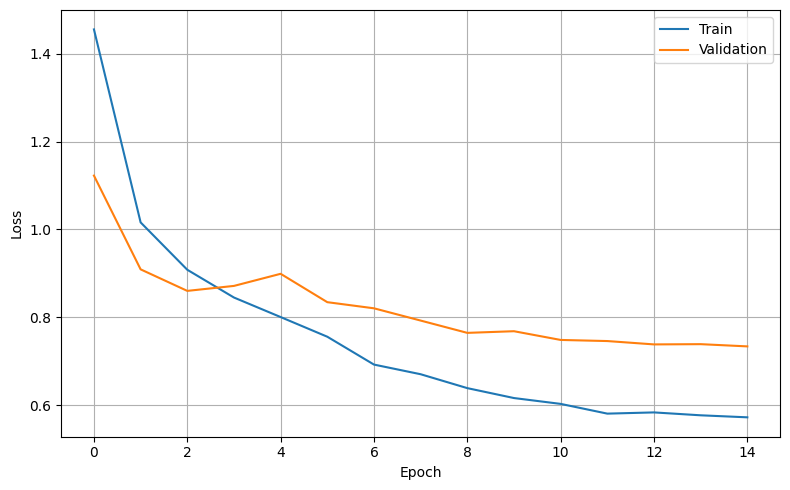

In [33]:
# ============================================
# CELL 30 — LOSS CURVE
# ============================================

plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")

plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/loss_curve.png",
    dpi=300
)

plt.show()

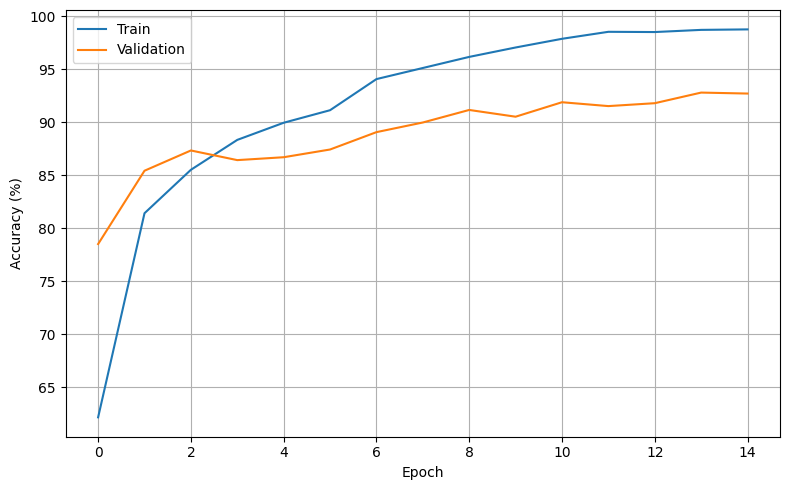

In [34]:
# ============================================
# CELL 31 — ACCURACY CURVE
# ============================================

plt.figure(figsize=(8,5))

plt.plot(train_accs,label="Train")

plt.plot(val_accs,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/accuracy_curve.png",
    dpi=300
)

plt.show()

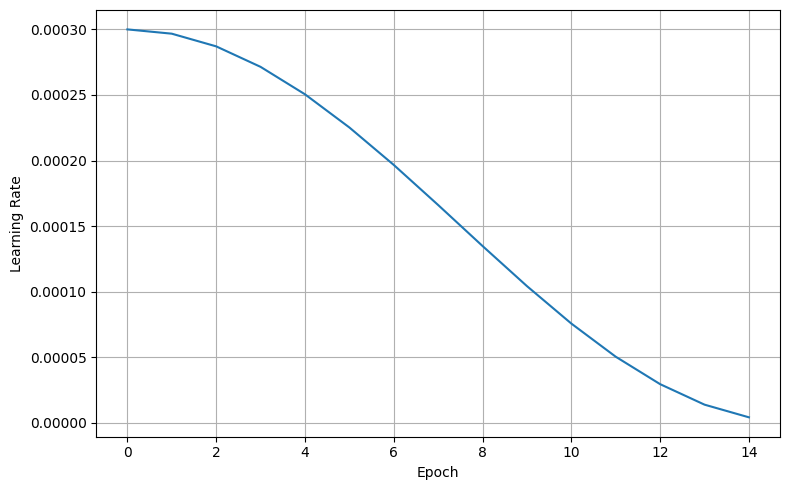

In [35]:
# ============================================
# CELL 32 — LR CURVE
# ============================================

plt.figure(figsize=(8,5))

plt.plot(learning_rates)

plt.xlabel("Epoch")

plt.ylabel("Learning Rate")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/lr_schedule.png",
    dpi=300
)

plt.show()

In [36]:
# ============================================
# CELL 33 — PREDICTIONS
# ============================================

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Prediction completed.")

100%|██████████| 35/35 [00:17<00:00,  1.99it/s]

Prediction completed.


In [38]:
# ============================================
# CELL 34 — PERFORMANCE METRICS
# ============================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("="*50)

print(f"Accuracy  : {accuracy*100:.2f}%")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print("="*50)

Accuracy  : 92.81%
Precision : 0.9286
Recall    : 0.9281
F1 Score  : 0.9274


In [39]:
# ============================================
# CELL 35 — CLASSIFICATION REPORT
# ============================================

report = classification_report(

    y_true,

    y_pred,

    target_names=train_dataset.dataset.classes,

    digits=4

)

print(report)

              precision    recall  f1-score   support

        ants     0.9700    0.9700    0.9700       100
        bees     0.9612    0.9900    0.9754       100
      beetle     0.9167    0.7952    0.8516        83
catterpillar     0.8068    0.8161    0.8114        87
  earthworms     0.8889    0.8615    0.8750        65
      earwig     0.9390    0.8280    0.8800        93
 grasshopper     0.8692    0.9588    0.9118        97
        moth     0.9612    1.0000    0.9802        99
        slug     0.8272    0.8590    0.8428        78
       snail     0.9901    1.0000    0.9950       100
        wasp     0.9802    0.9900    0.9851       100
      weevil     0.9796    0.9897    0.9846        97

    accuracy                         0.9281      1099
   macro avg     0.9242    0.9215    0.9219      1099
weighted avg     0.9286    0.9281    0.9274      1099



In [40]:
# ============================================
# CELL 36 — SAVE REPORT
# ============================================

with open(
    "/kaggle/working/classification_report.txt",
    "w"
) as f:

    f.write(report)

print("Classification report saved.")

Classification report saved.


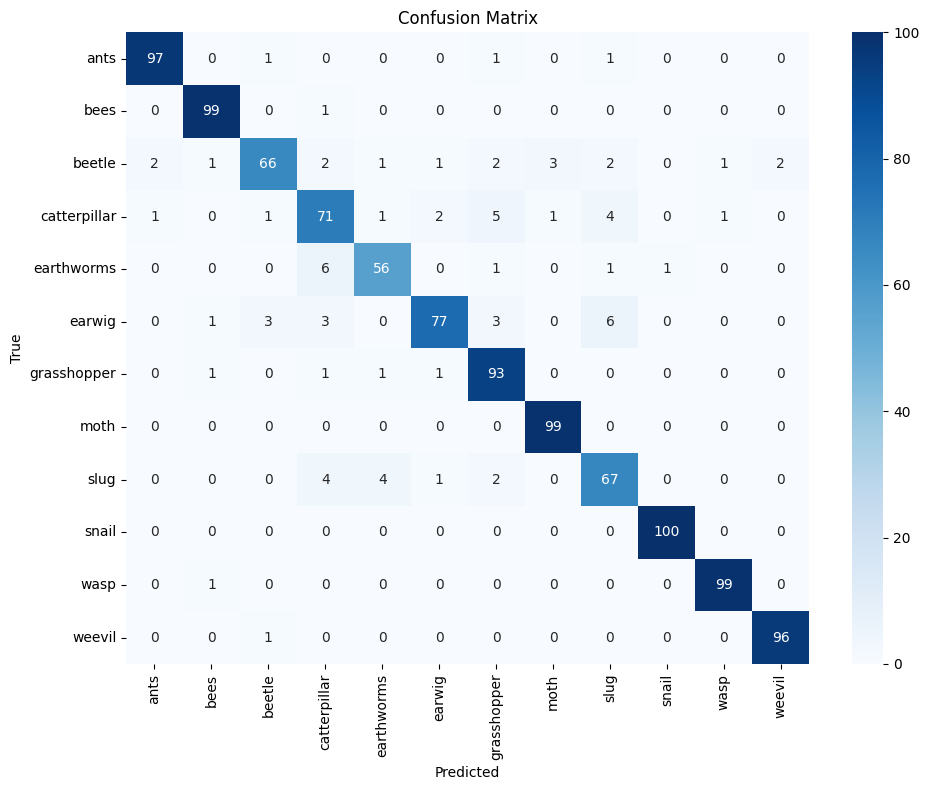

In [41]:
# ============================================
# CELL 37 — CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=train_dataset.dataset.classes,

    yticklabels=train_dataset.dataset.classes

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(

    "/kaggle/working/confusion_matrix.png",

    dpi=300

)

plt.show()

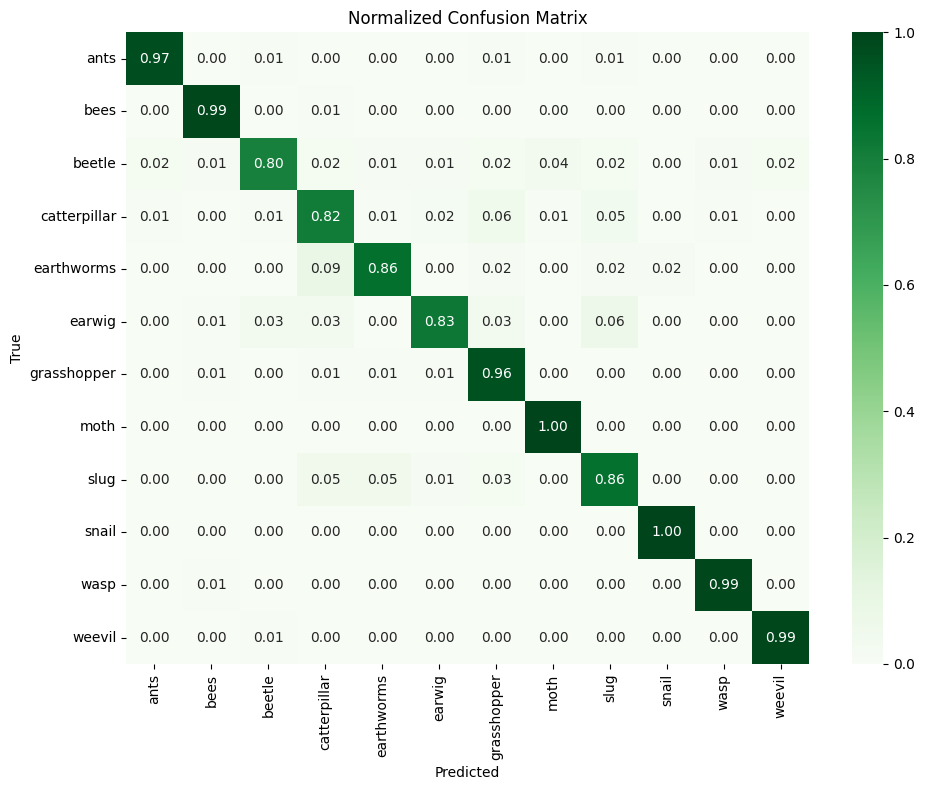

In [42]:
# ============================================
# CELL 38 — NORMALIZED CM
# ============================================

cm_norm = cm.astype(float)

cm_norm = cm_norm / cm_norm.sum(axis=1)[:,None]

plt.figure(figsize=(10,8))

sns.heatmap(

    cm_norm,

    annot=True,

    fmt=".2f",

    cmap="Greens",

    xticklabels=train_dataset.dataset.classes,

    yticklabels=train_dataset.dataset.classes

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Normalized Confusion Matrix")

plt.tight_layout()

plt.savefig(

    "/kaggle/working/confusion_matrix_normalized.png",

    dpi=300

)

plt.show()

In [43]:
# ============================================
# CELL 39 — METRIC TABLE
# ============================================

results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        accuracy*100,

        precision,

        recall,

        f1

    ]

})

display(results)

results.to_csv(

    "/kaggle/working/performance_metrics.csv",

    index=False

)

,Metric,Value
0,Accuracy,92.811647
1,Precision,0.928601
2,Recall,0.928116
3,F1 Score,0.927447


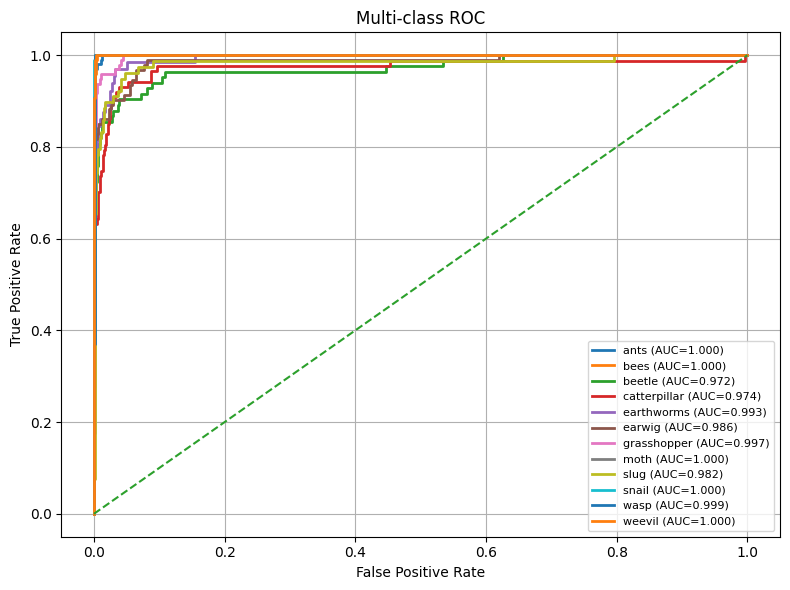

In [44]:
# ============================================
# CELL 40 — ROC CURVES
# ============================================

from sklearn.preprocessing import label_binarize

classes = len(train_dataset.dataset.classes)

y_true_bin = label_binarize(

    y_true,

    classes=np.arange(classes)

)

plt.figure(figsize=(8,6))

for i in range(classes):

    fpr, tpr, _ = roc_curve(

        y_true_bin[:,i],

        y_prob[:,i]

    )

    roc_auc = auc(fpr,tpr)

    plt.plot(

        fpr,

        tpr,

        lw=2,

        label=f"{train_dataset.dataset.classes[i]} (AUC={roc_auc:.3f})"

    )

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Multi-class ROC")

plt.legend(fontsize=8)

plt.grid()

plt.tight_layout()

plt.savefig(

    "/kaggle/working/roc_curve.png",

    dpi=300

)

plt.show()

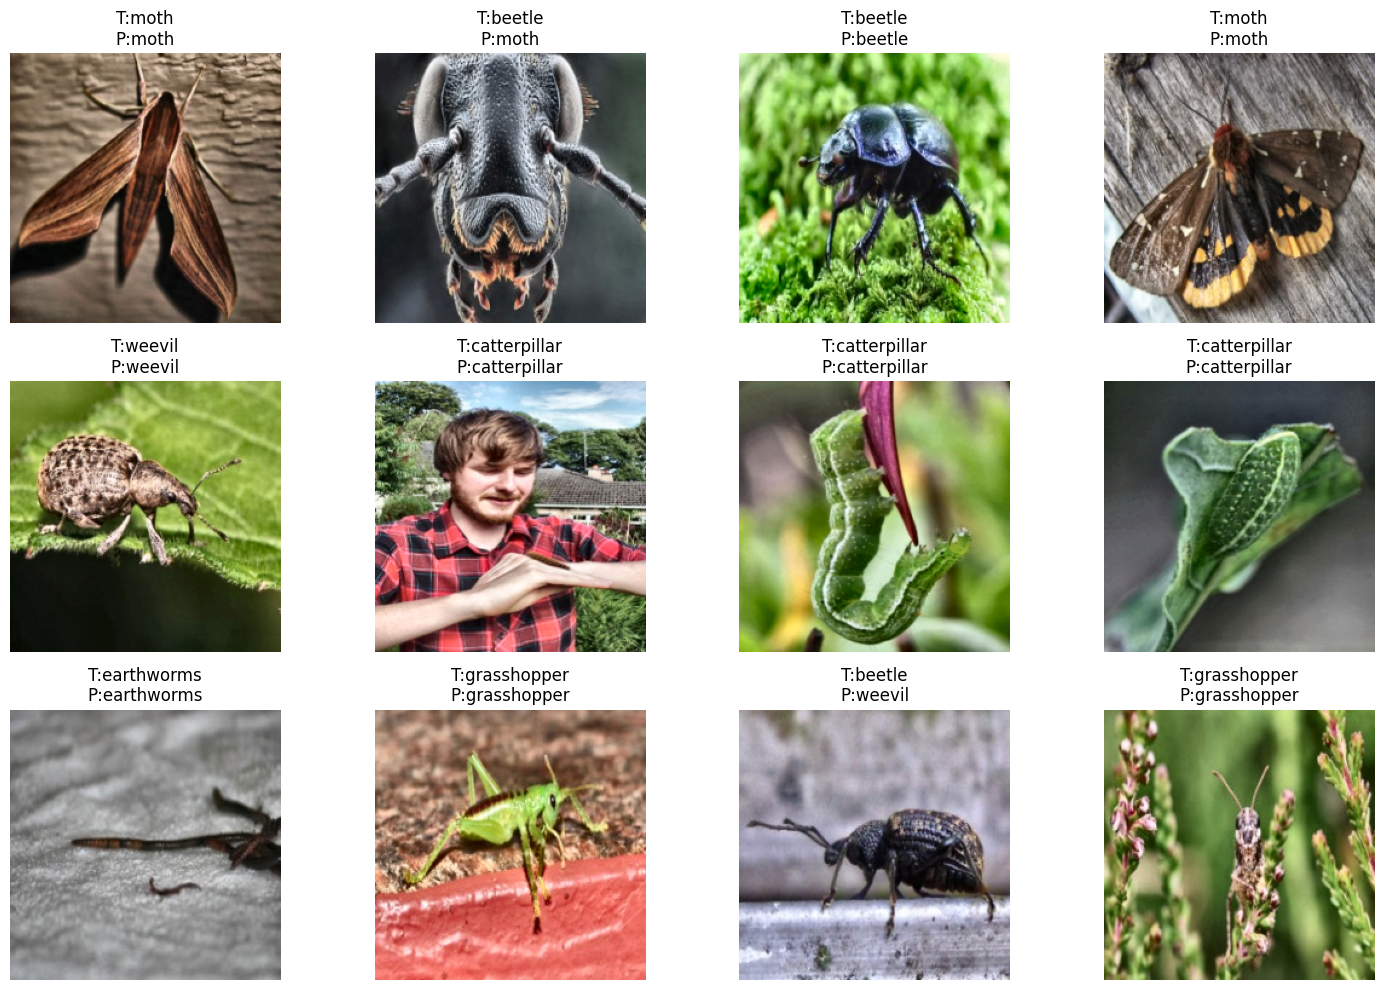

In [45]:
# ============================================
# CELL 41 — SAMPLE PREDICTIONS
# ============================================

images, labels = next(iter(val_loader))

images = images.to(device)

outputs = model(images)

preds = torch.argmax(outputs,1)

images = images.cpu()

preds = preds.cpu()

labels = labels.cpu()

plt.figure(figsize=(15,10))

for i in range(12):

    img = images[i]

    img = img.permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225])

    img = img + np.array([0.485,0.456,0.406])

    img = np.clip(img,0,1)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(

        f"T:{train_dataset.dataset.classes[labels[i]]}\n"

        f"P:{train_dataset.dataset.classes[preds[i]]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    "/kaggle/working/sample_predictions.png",

    dpi=300

)

plt.show()

In [46]:
# ============================================
# CELL 42 — SAVE MODEL
# ============================================

torch.save(

    model.state_dict(),

    "/kaggle/working/AFFN_Final_Model.pth"

)

print("Model saved successfully.")

Model saved successfully.


In [47]:
# ============================================
# CELL 43 — GENERALIZATION GAP
# ============================================

best_train_acc = max(train_accs)
best_val_acc = max(val_accs)

gap = best_train_acc - best_val_acc

print("="*60)
print("GENERALIZATION ANALYSIS")
print("="*60)

print(f"Best Training Accuracy   : {best_train_acc:.2f}%")
print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Generalization Gap       : {gap:.2f}%")

if gap < 10:
    print("\nGeneralization is good.")
elif gap < 15:
    print("\nModerate overfitting observed.")
else:
    print("\nSignificant overfitting observed.")

print("="*60)

GENERALIZATION ANALYSIS
Best Training Accuracy   : 98.77%
Best Validation Accuracy : 92.81%
Generalization Gap       : 5.96%

Generalization is good.
